# Session 4 homework: filters, Gaussian blur and Canny on MILK10k

**Author:** Sebastián Ríos Saucedo · Computer Vision & Speech Recognition · EADA

Three parts, following the homework statement:

1. **Explore filters across diagnosis classes.** Apply the same set of filters to dermoscopic images of benign and malignant lesions and check whether edges or textures look different. A small quantitative check on 80 random images backs up what the eye sees.
2. **Gaussian blur.** What the `sigma` parameter of `scipy.ndimage.gaussian_filter` controls, and what happens when it changes.
3. **Canny edge detection.** A from-scratch implementation (smoothing, gradients, non-maximum suppression, double threshold, hysteresis), applied to one MILK10k image and compared with a Sobel edge detector.

Only dermoscopic images are used, so every image comes from the same kind of device. Data paths come from `milk10k_pipeline/config.py`, nothing is hard-coded.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage, stats

# walk up the folders until we find the repo root (the folder that contains milk10k_pipeline/)
ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
            if (p / "milk10k_pipeline" / "config.py").is_file())
sys.path.insert(0, str(ROOT))
from milk10k_pipeline import config      # paths only (MILK10K_DATA_DIR or ../milk10k_project)

FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)
np.set_printoptions(precision=3, suppress=True)
print(config.describe())

DATA_DIR=/tmp/claude-0/-home-claude/9f31d8ec-ae29-56ab-8ced-3f6839bc1afb/scratchpad/hw/CVSR/milk10k_project | IMAGE_DIR=/tmp/claude-0/-home-claude/9f31d8ec-ae29-56ab-8ced-3f6839bc1afb/scratchpad/hw/CVSR/milk10k_project/images | SEED=42 | IMG_SIZE=224


In [2]:
def load_rgb(isic_id):
    return np.asarray(Image.open(config.image_path(isic_id)).convert("RGB"))

def load_gray(isic_id):
    """Grayscale float image in [0, 1] (filters need floats: negatives and decimals)."""
    return np.asarray(Image.open(config.image_path(isic_id)).convert("L"), dtype=float) / 255.0

meta = pd.read_csv(config.METADATA_CSV)
derm = meta[meta.image_type == "dermoscopic"].set_index("isic_id")

# One dermoscopic image per diagnosis class: 3 malignant + 3 benign.
# Picked from a seeded random sample (3 candidates per class, random_state=42),
# keeping the image where the lesion is fully visible.
EXAMPLES = {
    "Melanoma (invasive)":    "ISIC_0410802",
    "Basal cell carcinoma":   "ISIC_0880783",
    "Squamous cell carcinoma": "ISIC_0350483",
    "Nevus":                  "ISIC_2713587",
    "Seborrheic keratosis":   "ISIC_8698547",
    "Dermatofibroma":         "ISIC_7077229",
}
derm.loc[list(EXAMPLES.values()), ["diagnosis_1", "diagnosis_3", "anatom_site_general", "age_approx"]]

,diagnosis_1,diagnosis_3,anatom_site_general,age_approx
isic_id,,,,
ISIC_0410802,Malignant,Melanoma Invasive,NaN,45.0
ISIC_0880783,Malignant,Basal cell carcinoma,NaN,55.0
ISIC_0350483,Malignant,"Squamous cell carcinoma, Invasive",upper extremity,65.0
ISIC_2713587,Benign,Nevus,upper extremity,30.0
ISIC_8698547,Benign,Seborrheic keratosis,NaN,65.0
ISIC_7077229,Benign,Dermatofibroma,NaN,35.0


## Part 1. Same filters, different diagnosis classes

Five filters, all seen in class:

| Filter | What it answers |
|---|---|
| Gaussian blur (σ = 3) | What survives once fine detail is removed? |
| Sharpen (3×3) | Where is the local contrast? |
| Sobel gradient magnitude (after σ = 1 smoothing) | Where does intensity change, i.e. where are the **edges**? |
| \|Laplacian of Gaussian\| (σ = 2) | Where are small blobs and dots (dots, globules, pores)? |
| Local standard deviation (9×9) | How "busy" is each neighbourhood, i.e. **texture**? |

Every column of the figure uses **one common colour scale for all six images**, so a brighter panel really means a stronger response, not just a different auto-scaling.

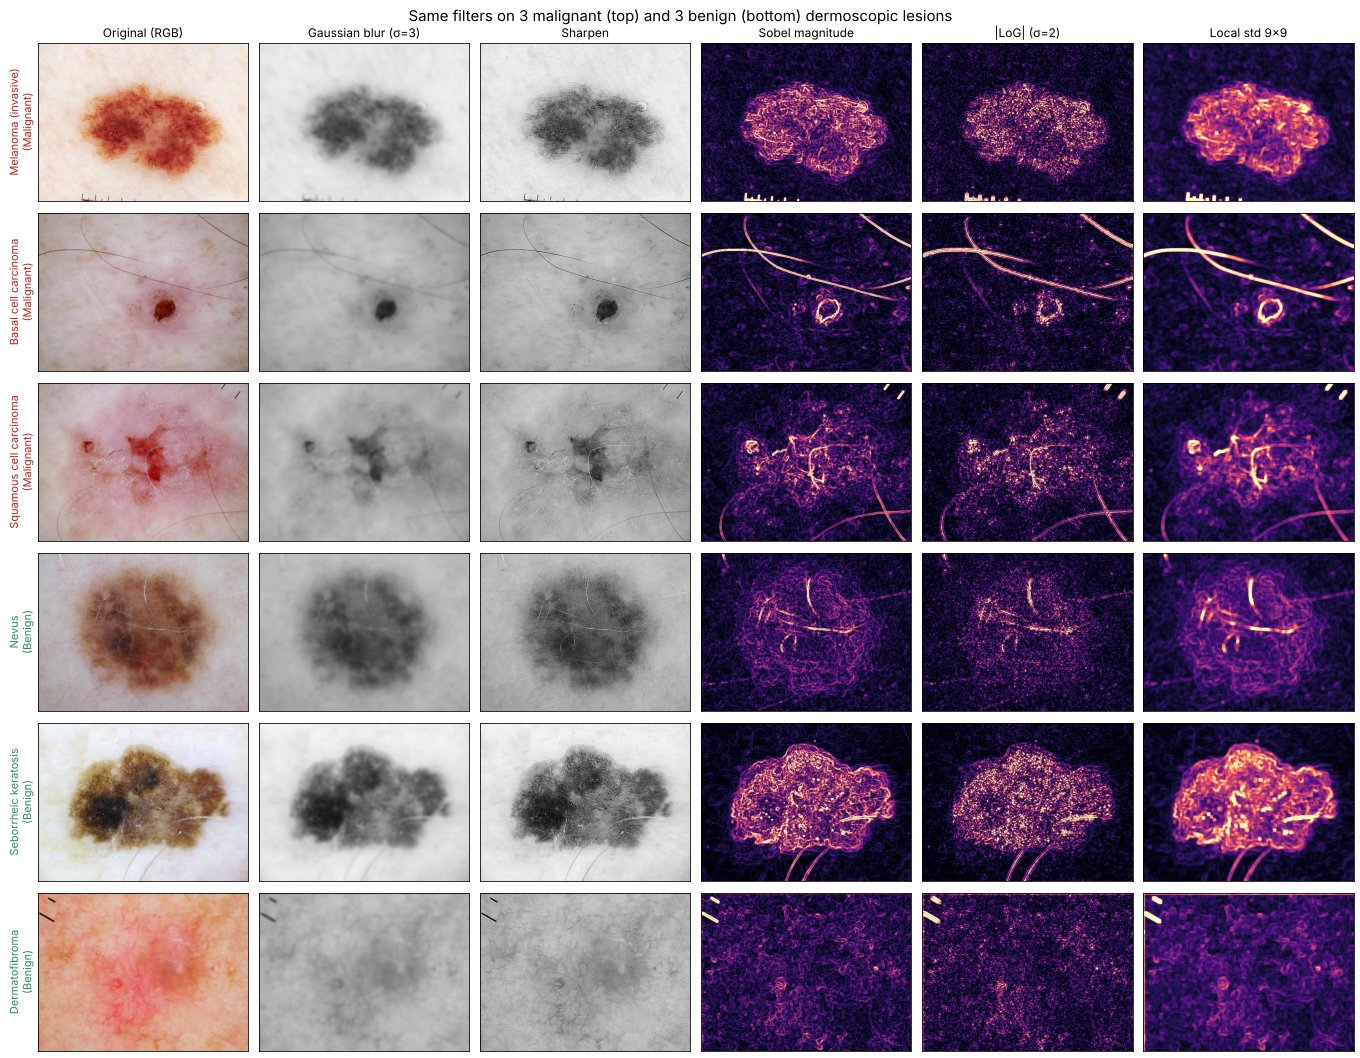

In [3]:
SHARPEN = np.array([[ 0, -1,  0],
                    [-1,  5, -1],
                    [ 0, -1,  0]], dtype=float)

def sobel_magnitude(gray, sigma=1.0):
    """Gradient magnitude sqrt(Gx^2 + Gy^2) with Sobel kernels, after optional Gaussian smoothing."""
    g = ndimage.gaussian_filter(gray, sigma) if sigma > 0 else gray
    gx = ndimage.sobel(g, axis=1)      # horizontal change -> vertical edges
    gy = ndimage.sobel(g, axis=0)      # vertical change   -> horizontal edges
    return np.hypot(gx, gy)

def local_std(gray, size=9):
    """Standard deviation inside a size x size window: a simple texture measure."""
    mean = ndimage.uniform_filter(gray, size)
    mean_sq = ndimage.uniform_filter(gray ** 2, size)
    return np.sqrt(np.clip(mean_sq - mean ** 2, 0, None))

FILTERS = {
    "Gaussian blur (σ=3)":  lambda g: ndimage.gaussian_filter(g, 3),
    "Sharpen":              lambda g: np.clip(ndimage.correlate(g, SHARPEN, mode="reflect"), 0, 1),
    "Sobel magnitude":      lambda g: sobel_magnitude(g, 1.0),
    "|LoG| (σ=2)":          lambda g: np.abs(ndimage.gaussian_laplace(g, 2)),
    "Local std 9×9":        lambda g: local_std(g, 9),
}

responses = {name: {f: fn(load_gray(iid)) for f, fn in FILTERS.items()}
             for name, iid in EXAMPLES.items()}

# common colour scale per filter column (99th percentile over the six images)
vmax = {f: np.percentile(np.concatenate([responses[n][f].ravel() for n in EXAMPLES]), 99)
        for f in FILTERS}
vmax["Gaussian blur (σ=3)"] = vmax["Sharpen"] = 1.0

fig, axes = plt.subplots(len(EXAMPLES), 1 + len(FILTERS), figsize=(19, 15))
for i, (name, iid) in enumerate(EXAMPLES.items()):
    group = derm.loc[iid, "diagnosis_1"]
    axes[i, 0].imshow(load_rgb(iid))
    axes[i, 0].set_ylabel(f"{name}\n({group})", fontsize=11,
                          color="firebrick" if group == "Malignant" else "seagreen")
    for j, f in enumerate(FILTERS, start=1):
        axes[i, j].imshow(responses[name][f], cmap="gray" if j <= 2 else "magma", vmin=0, vmax=vmax[f])
for j, title in enumerate(["Original (RGB)", *FILTERS]):
    axes[0, j].set_title(title, fontsize=12)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Same filters on 3 malignant (top) and 3 benign (bottom) dermoscopic lesions", fontsize=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "session4_hw_filters_by_class.png", dpi=80, bbox_inches="tight")
plt.show()

**What the six examples show (visual reading):**

* **Edges are dominated by things that are not the lesion.** On the basal cell carcinoma, the squamous cell carcinoma and the nevus, the strongest Sobel, |LoG| and local-std responses are the **hairs**, not the lesion border. On the melanoma and the dermatofibroma, the **ruler ticks and pen marks** at the image edge are as bright as anything inside the lesion. Any edge statistic computed on the whole image is partly a "hair and artefact counter".
* **Texture is high in both groups.** The melanoma (malignant) and the seborrheic keratosis (benign) have the busiest interiors of all six: Sobel, |LoG| and local std light up the whole lesion (pigment network, dots, crypts). So "lots of internal texture" is not a malignancy signature on its own; it is a property of strongly pigmented, structured lesions.
* **Borders differ in how sharp they are, not in a benign/malignant way.** The melanoma has a thick, bright but irregular outline that fades unevenly into the skin (in the profile it would be a slow ramp on some sides). The nevus outline is weak and diffuse, mostly hidden behind the hairs. The seborrheic keratosis has the sharpest "stuck-on" border. The BCC is a small dark crust with a clean ring, and the dermatofibroma has almost no edge at all.
* **Grayscale throws away the most useful cue for several malignant classes.** The SCC and the BCC are recognisable by red or pink areas and vessels. In grayscale these become low-contrast patches, so brightness-based filters respond weakly, and the same happens to the pink dermatofibroma.

In short: in single examples you can tell lesions apart by texture and border, but the filters respond to *pigmented structure*, *hair* and *artefacts* at least as much as to anything specific to malignancy.

Six images can always be cherry-picked, so the next cell checks the same idea on a larger random sample.

### Part 1b. Quick quantitative check on 40 benign + 40 malignant random images

For each image I compute three numbers:

* **Lesion texture:** mean local std *inside* the lesion.
* **Lesion border strength:** mean Sobel magnitude on a thin ring around the lesion border.
* **Whole-image edges:** mean Sobel magnitude over the full image (skin, hair and lesion together).

The lesion mask is a rough automatic one: Otsu threshold on the blurred grayscale image (lesions are darker than skin), the largest dark region that does not touch the image frame, and holes filled. It is good enough for a sanity check, not a real segmentation. The groups are compared with a Mann–Whitney U test, because there are only 40 images per group and the values are not normally distributed.

group      class                            
Benign     Nevus                                18
           Seborrheic keratosis                 10
           Dermatofibroma                        5
           Lichen planus like keratosis          4
           Solar lentigo                         2
           Infundibular or epidermal cyst        1
Malignant  Basal cell carcinoma                 28
           Melanoma Invasive                     4
           Melanoma in situ                      4
           Squamous cell carcinoma, Invasive     3
           Keratoacanthoma                       1

median lesion-mask area (fraction of image):
group
Benign       0.103
Malignant    0.007


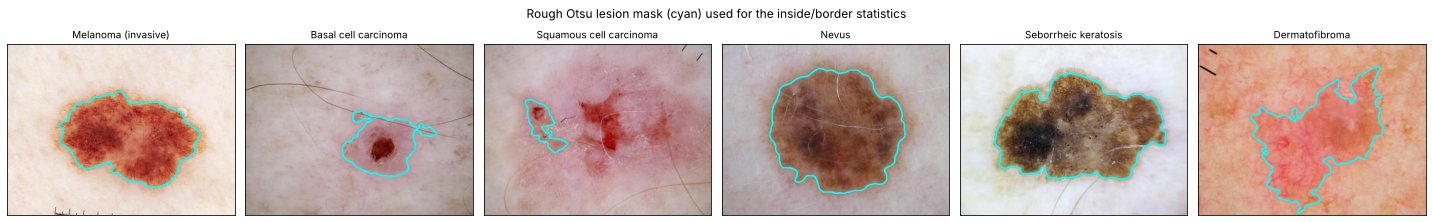

In [4]:
def otsu_threshold(x, bins=256):
    """Otsu's method: the threshold that maximises the between-class variance."""
    hist, edges = np.histogram(x, bins=bins, range=(0, 1))
    p = hist / hist.sum()
    centers = (edges[:-1] + edges[1:]) / 2
    w0 = np.cumsum(p)
    w1 = 1 - w0
    m0 = np.cumsum(p * centers)
    between = (m0[-1] * w0 - m0) ** 2 / (w0 * w1 + 1e-12)
    return centers[np.argmax(between)]

def lesion_mask(gray):
    """Rough lesion mask: dark blob after blur + Otsu, ignoring regions that touch the frame (vignetting)."""
    g = ndimage.gaussian_filter(gray, 5)
    mask = ndimage.binary_opening(g < otsu_threshold(g), iterations=3)
    labels, n = ndimage.label(mask)
    if n == 0:
        return mask
    touches = set(np.unique(np.concatenate([labels[0], labels[-1], labels[:, 0], labels[:, -1]])))
    sizes = ndimage.sum(mask, labels, range(1, n + 1))
    candidates = [k for k in range(1, n + 1) if k not in touches] or list(range(1, n + 1))
    best = max(candidates, key=lambda k: sizes[k - 1])
    return ndimage.binary_fill_holes(labels == best)

def edge_texture_features(isic_id):
    gray = load_gray(isic_id)
    mask = lesion_mask(gray)
    ring = ndimage.binary_dilation(mask, iterations=4) & ~ndimage.binary_erosion(mask, iterations=4)
    sob = sobel_magnitude(gray, 1.0)
    return {
        "lesion_texture (local std inside)": local_std(gray, 9)[mask].mean(),
        "border_strength (Sobel on border)": sob[ring].mean(),
        "whole_image_edges (Sobel, all px)": sob.mean(),
        "lesion_area_frac": mask.mean(),
    }

sample = pd.concat([derm[derm.diagnosis_1 == g].sample(40, random_state=config.SEED)
                    for g in ["Benign", "Malignant"]])
feats = pd.DataFrame([edge_texture_features(i) for i in sample.index], index=sample.index)
feats["group"] = sample["diagnosis_1"]
feats["class"] = sample["diagnosis_3"]
print(feats.groupby("group")["class"].value_counts().to_string())
print("\nmedian lesion-mask area (fraction of image):")
print(feats.groupby("group")["lesion_area_frac"].median().round(3).to_string())

# what the rough mask looks like on the six examples
fig, axes = plt.subplots(1, 6, figsize=(20, 3.2))
for ax, (name, iid) in zip(axes, EXAMPLES.items()):
    ax.imshow(load_rgb(iid))
    ax.contour(lesion_mask(load_gray(iid)), levels=[0.5], colors="cyan", linewidths=1.5)
    ax.set_title(name, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Rough Otsu lesion mask (cyan) used for the inside/border statistics", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
FEATURES = ["lesion_texture (local std inside)", "border_strength (Sobel on border)",
            "whole_image_edges (Sobel, all px)"]
rows = []
for f in FEATURES:
    b = feats.loc[feats.group == "Benign", f]
    m = feats.loc[feats.group == "Malignant", f]
    u, p = stats.mannwhitneyu(b, m, alternative="two-sided")
    rows.append({"feature": f, "median benign": b.median(), "median malignant": m.median(),
                 "Mann-Whitney p": p})
summary = pd.DataFrame(rows).set_index("feature")
summary.round(4)

,median benign,median malignant,Mann-Whitney p
feature,,,
lesion_texture (local std inside),0.0278,0.0230,0.1890
border_strength (Sobel on border),0.1000,0.0644,0.0339
"whole_image_edges (Sobel, all px)",0.0523,0.0463,0.5933


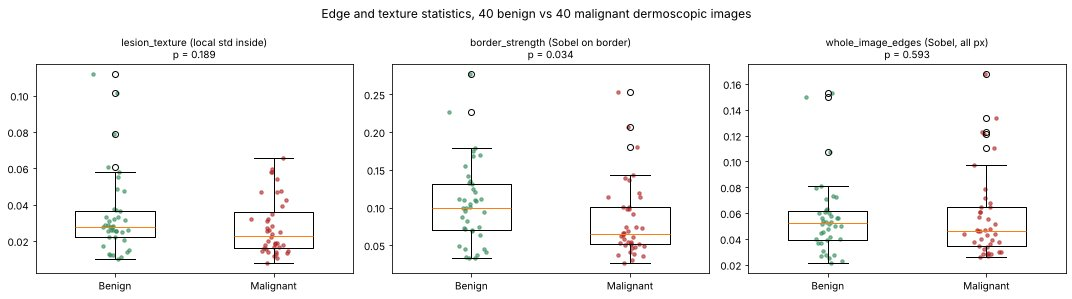

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, f in zip(axes, FEATURES):
    data = [feats.loc[feats.group == g, f] for g in ["Benign", "Malignant"]]
    ax.boxplot(data, widths=0.5)
    for k, (d, c) in enumerate(zip(data, ["seagreen", "firebrick"]), start=1):
        ax.scatter(np.random.default_rng(0).normal(k, 0.06, len(d)), d, s=12, alpha=0.6, color=c)
    ax.set_xticks([1, 2], ["Benign", "Malignant"])
    ax.set_title(f"{f}\np = {summary.loc[f, 'Mann-Whitney p']:.3f}", fontsize=10)
fig.suptitle("Edge and texture statistics, 40 benign vs 40 malignant dermoscopic images", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "session4_hw_edge_texture_stats.png", dpi=110, bbox_inches="tight")
plt.show()

**Reading the numbers.**

* **Texture inside the lesion** (local std): medians are close (benign slightly higher) and the difference is not significant.
* **Border strength**: *benign* lesions have the **stronger** border on average (p ≈ 0.03). This is the opposite of a naive "malignant = sharper edges" expectation, and the reason is the class mix. Most benign images are dark pigmented nevi and seborrheic keratoses with high contrast to the skin, while most malignant images (28 of 40) are basal cell carcinomas, which are often pale pink and barely darker than the skin in grayscale. With three tests, p = 0.03 is also not significant after a Bonferroni correction (0.03 × 3 ≈ 0.10).
* **Whole-image edges**: no difference at all, because hair, rulers and skin texture dominate.
* **The mask itself tells the same story:** the median lesion mask is much smaller for malignant images, because a dark-region threshold does not find pale, non-pigmented lesions well.

**Answer to the question:** in individual images, edges and textures do look different between lesions, but on a random sample the hand-crafted edge and texture numbers **overlap heavily** between benign and malignant. The differences they show are driven by pigmentation, hair and the mix of diagnoses rather than by malignancy itself. A single filter is not a classifier. This is why a CNN learns many filters, on colour images, and combines them.

## Part 2. Gaussian blur: what does `sigma` control?

From the `scipy.ndimage.gaussian_filter(input, sigma, order=0, mode='reflect', cval=0.0, truncate=4.0, radius=None, axes=None)` documentation:

* **`sigma` is the standard deviation of the Gaussian kernel, in pixels.** It sets how wide the bell curve is, i.e. how far away a neighbour can be and still contribute to the weighted average. Small σ means mostly the pixel itself and its immediate neighbours (light blur). Large σ means a wide neighbourhood (strong blur).
* It can be **one number** (same blur on both axes) or **one value per axis**, e.g. `sigma=(0, 5)` blurs only horizontally.
* The kernel is not infinite: it is cut at **`truncate × sigma`** pixels (default 4σ), so the kernel radius is `int(truncate * sigma + 0.5)`. A bigger σ therefore also means a bigger and slower kernel.
* The weights always sum to 1, so blurring **does not change the average brightness**; it only spreads it.
* Frequency view: a Gaussian is a low-pass filter. Detail smaller than roughly σ pixels (noise, hair, pigment dots) is removed first, and large structures (the lesion shape) survive longer.
* `sigma = 0` leaves the image unchanged. `order` > 0 gives derivatives of the Gaussian instead of plain blur, which is the trick Canny uses below.

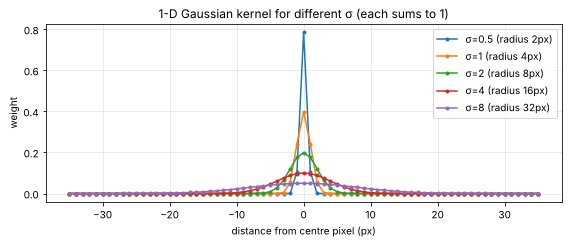

In [7]:
sigmas = [0.5, 1, 2, 4, 8]
x = np.arange(-35, 36)
impulse = np.zeros_like(x, dtype=float)
impulse[35] = 1.0
plt.figure(figsize=(8, 3.5))
for s in sigmas:
    radius = int(4.0 * s + 0.5)
    plt.plot(x, ndimage.gaussian_filter1d(impulse, s), marker=".", label=f"σ={s} (radius {radius}px)")
plt.xlabel("distance from centre pixel (px)")
plt.ylabel("weight")
plt.title("1-D Gaussian kernel for different σ (each sums to 1)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "session4_hw_gaussian_kernels.png", dpi=110, bbox_inches="tight")
plt.show()

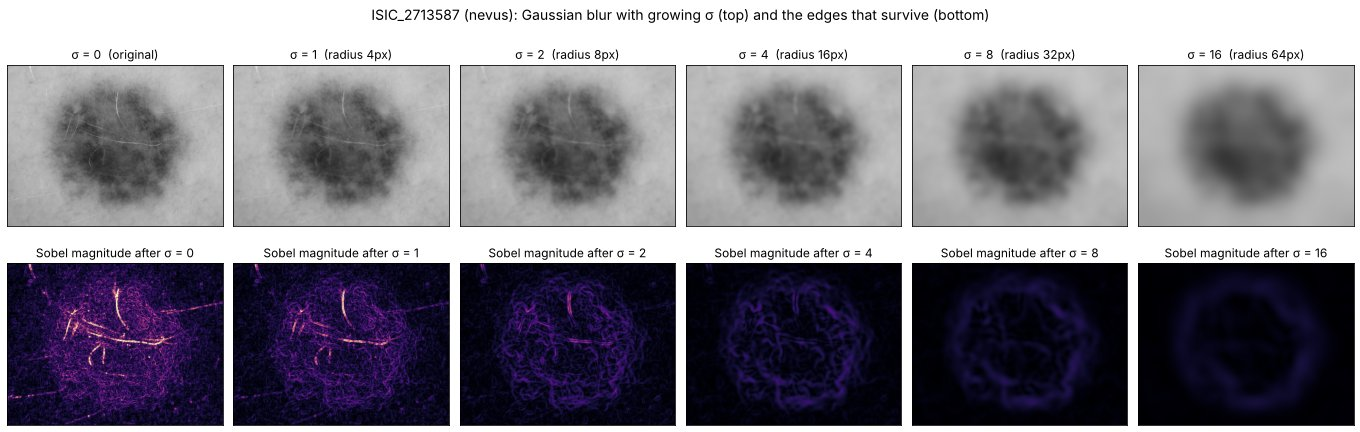

In [8]:
SIGMA_ID = EXAMPLES["Nevus"]          # pigmented lesion with hairs crossing it: good for seeing what blur removes
gray = load_gray(SIGMA_ID)
sigma_grid = [0, 1, 2, 4, 8, 16]
blurred = {s: (gray if s == 0 else ndimage.gaussian_filter(gray, s)) for s in sigma_grid}

fig, axes = plt.subplots(2, len(sigma_grid), figsize=(19, 6.5))
for j, s in enumerate(sigma_grid):
    axes[0, j].imshow(blurred[s], cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"σ = {s}" + ("  (original)" if s == 0 else f"  (radius {int(4*s+0.5)}px)"))
    axes[1, j].imshow(sobel_magnitude(blurred[s], 0), cmap="magma", vmin=0, vmax=0.5)
    axes[1, j].set_title(f"Sobel magnitude after σ = {s}")
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"{SIGMA_ID} (nevus): Gaussian blur with growing σ (top) and the edges that survive (bottom)", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "session4_hw_gaussian_sigma.png", dpi=110, bbox_inches="tight")
plt.show()

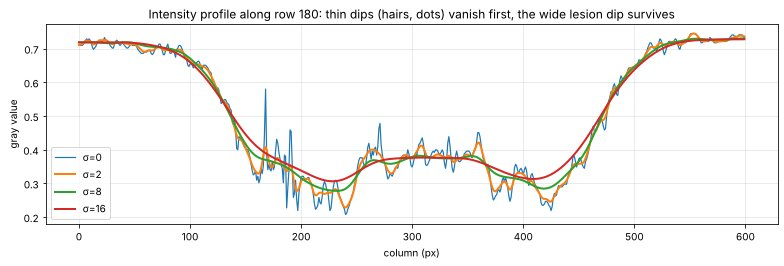

,kernel radius (px),mean brightness,pixel std,mean Sobel magnitude
sigma,,,,
0,0,0.5813,0.1613,0.0726
1,4,0.5813,0.1607,0.0505
2,8,0.5813,0.1602,0.0349
4,16,0.5813,0.1594,0.0244
8,32,0.5813,0.1577,0.0186
16,64,0.5813,0.1533,0.0151


In [9]:
row = 180                              # horizontal line through the lesion and a hair
plt.figure(figsize=(11, 3.8))
for s in [0, 2, 8, 16]:
    plt.plot(blurred[s][row], label=f"σ={s}", lw=1.2 if s == 0 else 2)
plt.xlabel("column (px)")
plt.ylabel("gray value")
plt.title(f"Intensity profile along row {row}: thin dips (hairs, dots) vanish first, the wide lesion dip survives")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "session4_hw_gaussian_profile.png", dpi=110, bbox_inches="tight")
plt.show()

stats_sigma = pd.DataFrame({
    "sigma": sigma_grid,
    "kernel radius (px)": [0] + [int(4 * s + 0.5) for s in sigma_grid[1:]],
    "mean brightness": [blurred[s].mean() for s in sigma_grid],
    "pixel std": [blurred[s].std() for s in sigma_grid],
    "mean Sobel magnitude": [sobel_magnitude(blurred[s], 0).mean() for s in sigma_grid],
}).set_index("sigma")
stats_sigma.round(4)

**Observations on σ (nevus with hairs):**

* **σ = 1** removes JPEG noise and the finest pigment dots. Hairs and border look the same, and the edge map is already cleaner.
* **σ = 2–4** is the useful range for a 600×450 image. Thin hairs fade, their edge response drops sharply (in the bottom row the bright hair lines are almost gone at σ = 4), and the lesion outline is still clearly visible.
* **σ = 8–16** blurs the lesion itself. The border becomes a wide, soft ramp, the edge map only shows a faint fuzzy ring, and the internal structure is gone. In the intensity profile, the hair spike near column 170 and the small dips vanish already at σ = 2, while the wide lesion "valley" survives even at σ = 16, only with softer walls.
* **Mean brightness is identical for every σ** (the weights sum to 1). What falls is the edge strength: the mean Sobel magnitude drops from 0.073 (σ = 0) to 0.035 (σ = 2) and 0.015 (σ = 16). The pixel std barely changes, because most of the variance comes from the large lesion-vs-skin difference, which blur keeps.
* So **σ is a scale knob**: it decides the size of the details you keep. For MILK10k, a small σ (1–2) before edge detection is a cheap way to remove noise, but no σ removes hair without also softening the lesion border, because hairs (a few pixels wide) and fine pigment structures live at the same scale.

## Part 3. Canny edge detector, implemented from scratch

Canny (1986) designed an edge detector with three goals: find real edges and few false ones, put the edge in the right place, and give **one** response per edge. The algorithm has five steps:

1. **Gaussian smoothing** with σ, to reduce noise (Part 2).
2. **Gradient** with Sobel kernels: magnitude `sqrt(Gx² + Gy²)` and direction `atan2(Gy, Gx)`.
3. **Non-maximum suppression (NMS):** keep a pixel only if its magnitude is the largest along the gradient direction (compared with its two neighbours across the edge). This thins thick ridges to 1-pixel lines.
4. **Double threshold:** pixels above `high` are **strong** edges, pixels between `low` and `high` are **weak**, and everything else is dropped.
5. **Edge tracking by hysteresis:** a weak pixel is kept only if it is connected (8-neighbourhood) to a strong pixel. This keeps long contours unbroken while discarding isolated noise.

Below, `low` and `high` are given as fractions of the maximum gradient after NMS.

In [10]:
def non_max_suppression(mag, angle_deg):
    """Keep only local maxima of `mag` along the gradient direction (quantised to 0/45/90/135 deg)."""
    H, W = mag.shape
    P = np.pad(mag, 1)
    def neighbour(dy, dx):                       # value of the neighbour at offset (dy, dx) for every pixel
        return P[1 + dy:H + 1 + dy, 1 + dx:W + 1 + dx]
    a = angle_deg % 180
    directions = {
        "0":   ((a < 22.5) | (a >= 157.5), (0, 1), (0, -1)),    # gradient horizontal -> compare left/right
        "45":  ((a >= 22.5) & (a < 67.5),  (1, 1), (-1, -1)),   # gradient down-right (y axis points down)
        "90":  ((a >= 67.5) & (a < 112.5), (1, 0), (-1, 0)),    # gradient vertical -> compare up/down
        "135": ((a >= 112.5) & (a < 157.5), (1, -1), (-1, 1)),  # gradient down-left
    }
    out = np.zeros_like(mag)
    for in_dir, n1, n2 in directions.values():
        keep = in_dir & (mag >= neighbour(*n1)) & (mag >= neighbour(*n2))
        out[keep] = mag[keep]
    return out


def canny(gray, sigma=2.0, low=0.08, high=0.20, return_steps=False):
    """Canny edge detector.

    gray      : 2-D float image
    sigma     : std of the Gaussian smoothing (step 1)
    low, high : hysteresis thresholds as fractions of the max NMS gradient
    returns   : boolean edge map (and the intermediate images if return_steps=True)
    """
    # 1. smoothing
    smooth = ndimage.gaussian_filter(gray, sigma)
    # 2. gradient magnitude and direction (Sobel)
    gx = ndimage.sobel(smooth, axis=1)
    gy = ndimage.sobel(smooth, axis=0)
    mag = np.hypot(gx, gy)
    angle = np.rad2deg(np.arctan2(gy, gx))
    # 3. non-maximum suppression -> thin ridges
    thin = non_max_suppression(mag, angle)
    # 4. double threshold
    hi_t, lo_t = high * thin.max(), low * thin.max()
    strong = thin >= hi_t
    weak = (thin >= lo_t) & ~strong
    # 5. hysteresis: keep weak pixels only if their connected component contains a strong pixel
    labels, _ = ndimage.label(strong | weak, structure=np.ones((3, 3)))
    keep_label = np.zeros(labels.max() + 1, dtype=bool)
    keep_label[np.unique(labels[strong])] = True
    keep_label[0] = False
    edges = keep_label[labels]
    if return_steps:
        return edges, {"1. smoothed (σ=%g)" % sigma: smooth, "2. gradient magnitude": mag,
                       "3. after NMS": thin, "4. strong (white) / weak (gray)": strong * 1.0 + weak * 0.5,
                       "5. final edges (hysteresis)": edges}
    return edges

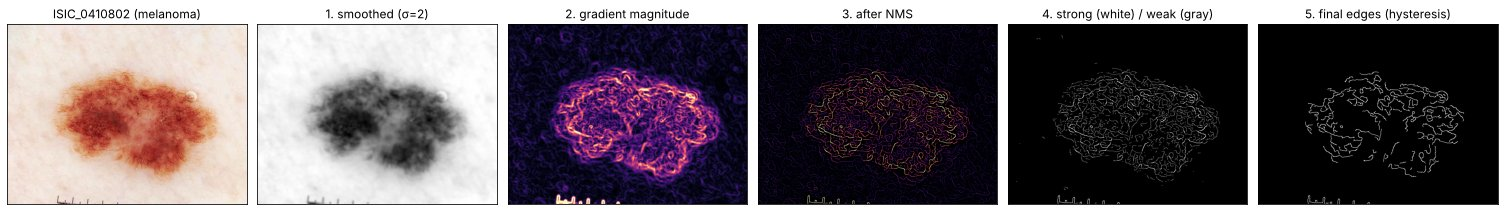

In [11]:
CANNY_ID = EXAMPLES["Melanoma (invasive)"]
gray = load_gray(CANNY_ID)
edges, steps = canny(gray, sigma=2.0, low=0.08, high=0.20, return_steps=True)

fig, axes = plt.subplots(1, 6, figsize=(21, 3.8))
axes[0].imshow(load_rgb(CANNY_ID)); axes[0].set_title(f"{CANNY_ID} (melanoma)")
for ax, (title, img) in zip(axes[1:], steps.items()):
    ax.imshow(img, cmap="gray" if "magnitude" not in title and "NMS" not in title else "magma",
              vmax=None if img.dtype == bool else np.percentile(img, 99.7))
    ax.set_title(title)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(FIG_DIR / "session4_hw_canny_steps.png", dpi=110, bbox_inches="tight")
plt.show()

### Canny vs Sobel on the same image

For a fair comparison, both detectors get the **same Gaussian pre-smoothing (σ = 2)**. "Sobel" is the gradient magnitude, either shown as it is (a continuous map) or thresholded to a binary edge map with a single threshold. Canny is the function above.

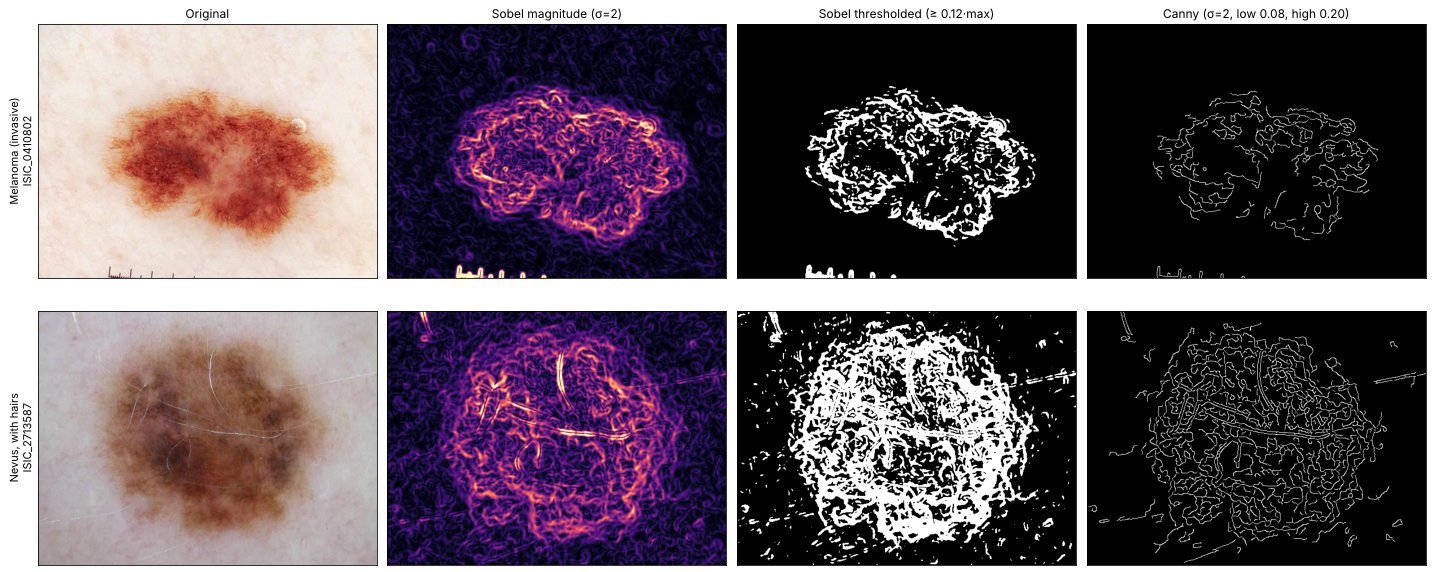

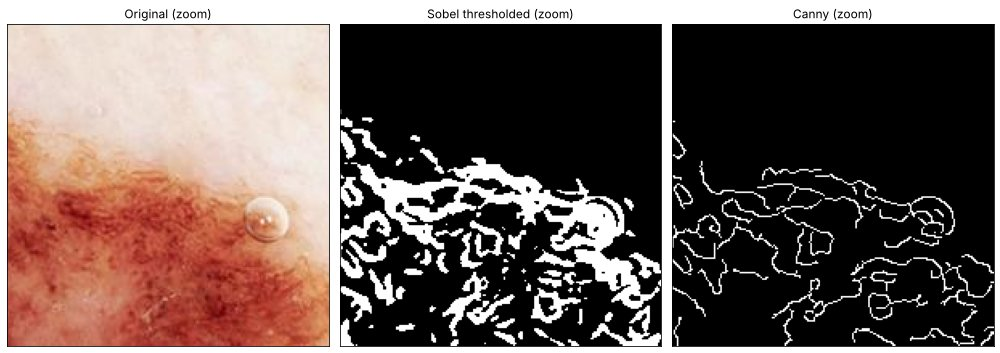

% edge pixels  ...  approx. line width (px)
image               detector                          ...                         
Melanoma (invasive) Sobel thresholded           9.41  ...                     3.67
                    Canny                       2.00  ...                     1.00
Nevus, with hairs   Sobel thresholded          32.12  ...                     4.26
                    Canny                       6.09  ...                     1.00

[4 rows x 3 columns]

In [12]:
SOBEL_T = 0.12          # single Sobel threshold, between Canny's low (0.08) and high (0.20)
fig, axes = plt.subplots(2, 4, figsize=(20, 8.6))
results = {}
for r, (name, iid) in enumerate([("Melanoma (invasive)", CANNY_ID), ("Nevus, with hairs", EXAMPLES["Nevus"])]):
    g = load_gray(iid)
    sob = sobel_magnitude(g, 2.0)
    s_edges = sob >= SOBEL_T * sob.max()
    c_edges = canny(g, sigma=2.0, low=0.08, high=0.20)
    results[name] = (s_edges, c_edges, sob)
    axes[r, 0].imshow(load_rgb(iid)); axes[r, 0].set_ylabel(f"{name}\n{iid}", fontsize=11)
    axes[r, 1].imshow(sob, cmap="magma", vmax=np.percentile(sob, 99.7))
    axes[r, 2].imshow(s_edges, cmap="gray")
    axes[r, 3].imshow(c_edges, cmap="gray")
for j, t in enumerate(["Original", "Sobel magnitude (σ=2)", f"Sobel thresholded (≥ {SOBEL_T}·max)",
                       "Canny (σ=2, low 0.08, high 0.20)"]):
    axes[0, j].set_title(t, fontsize=12)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(FIG_DIR / "session4_hw_canny_vs_sobel.png", dpi=110, bbox_inches="tight")
plt.show()

sobel_edges, edges, sob = results["Melanoma (invasive)"]

# zoom on the melanoma border to see thickness and continuity
ys, xs = slice(60, 260), slice(300, 500)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
axes[0].imshow(load_rgb(CANNY_ID)[ys, xs]); axes[0].set_title("Original (zoom)")
axes[1].imshow(sobel_edges[ys, xs], cmap="gray"); axes[1].set_title("Sobel thresholded (zoom)")
axes[2].imshow(edges[ys, xs], cmap="gray"); axes[2].set_title("Canny (zoom)")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(FIG_DIR / "session4_hw_canny_vs_sobel_zoom.png", dpi=110, bbox_inches="tight")
plt.show()

def n_segments(binary):
    return ndimage.label(binary, structure=np.ones((3, 3)))[1]

def approx_line_width(binary, nms):
    """edge pixels / edge pixels that are also ridge maxima  ~ average line thickness in px"""
    return binary.sum() / max((binary & (nms > 0)).sum(), 1)

rows = []
for name, (s_edges, c_edges, _) in results.items():
    nms = canny(load_gray(EXAMPLES["Nevus"] if "Nevus" in name else CANNY_ID), 2.0, return_steps=True)[1]["3. after NMS"]
    for det, e in [("Sobel thresholded", s_edges), ("Canny", c_edges)]:
        rows.append({"image": name, "detector": det, "% edge pixels": 100 * e.mean(),
                     "connected segments": n_segments(e), "approx. line width (px)": approx_line_width(e, nms)})
comparison = pd.DataFrame(rows).set_index(["image", "detector"])
comparison.round(2)

### Effect of σ on Canny, and a check against OpenCV

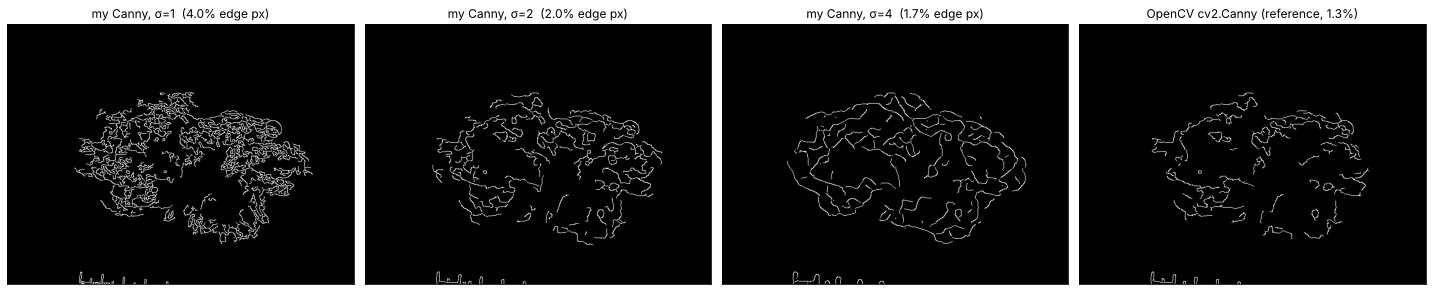

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))
for ax, s in zip(axes[:3], [1, 2, 4]):
    e = canny(gray, sigma=s)
    ax.imshow(e, cmap="gray"); ax.set_title(f"my Canny, σ={s}  ({100*e.mean():.1f}% edge px)")
try:
    import cv2
    u8 = (ndimage.gaussian_filter(gray, 2.0) * 255).astype(np.uint8)
    ref = cv2.Canny(u8, 20, 50, L2gradient=True) > 0
    axes[3].imshow(ref, cmap="gray"); axes[3].set_title(f"OpenCV cv2.Canny (reference, {100*ref.mean():.1f}%)")
except ImportError:
    axes[3].text(0.5, 0.5, "OpenCV not installed", ha="center");
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(FIG_DIR / "session4_hw_canny_sigma.png", dpi=110, bbox_inches="tight")
plt.show()

**Main differences between Canny and Sobel:**

1. **Thin vs thick edges.** Sobel responds on both sides of a boundary, so its thresholded edges are bands about 4 px wide (see the "approx. line width" column). Canny's non-maximum suppression keeps only the ridge top, so its edges are **1 px wide** and better localised. This is clearest in the zoom.
2. **Continuous map vs clean binary decision.** Sobel gives an edge *strength* map, and a single threshold is a bad compromise. On the melanoma it keeps short, broken blobs; on the nevus the same rule marks about a third of the image as "edge", because the hairs set the maximum and the skin texture passes the threshold. Canny's double threshold plus hysteresis keeps weak pixels only when they connect to a strong edge, so the output stays sparse (a few % of pixels) on both images.
3. **Connected contours.** Hysteresis lets Canny follow a faint stretch of contour as long as it touches a strong one. On the melanoma this gives fewer, longer curves than Sobel (122 vs 224 segments). On the nevus Canny has *more* segments, but only because Sobel's thick bands merge hair, skin texture and lesion into a few huge blobs, which is worse, not better.
4. **Scale is explicit in Canny.** With σ = 1 Canny traces the pigment network inside the melanoma, with σ = 4 mostly the large blobs and the outer outline. Plain 3×3 Sobel has a fixed, very small scale and is noise-sensitive without pre-smoothing.
5. **What neither fixes.** Both detectors fire on **hairs** (Canny turns each hair into two clean parallel lines) and on artefacts such as the **ruler ticks** and the **air bubble** on the melanoma, because those are genuine intensity edges. On the melanoma, Canny at σ = 2 finds the internal pigment boundaries more than the outer border, because the border fades gradually and its gradient is weaker than the internal contrasts. Neither method knows what a lesion is.
6. **Cost.** Canny is 5 steps with 3 parameters (σ, low, high) and is slower; Sobel is two small convolutions. My implementation gives edge maps very close to OpenCV's `cv2.Canny`, which is a good sign that the steps are correct.

## Conclusions

* **Do edges or textures look different between malignant and benign lesions?** Lesion by lesion, yes: texture and border sharpness vary a lot between diagnoses. But they do not split along benign vs malignant. Highly textured lesions exist in both groups (melanoma and seborrheic keratosis), and on 80 random images the hand-crafted edge and texture statistics overlap heavily. The only borderline difference (border strength, higher in *benign*) is explained by pigmentation and the class mix, not by malignancy. Hair, rulers and the loss of colour in grayscale are the main confounders.
* **σ in `gaussian_filter`** is the standard deviation of the Gaussian kernel in pixels: the scale of detail that gets removed. Small σ removes noise, σ ≈ 2–4 removes most hair and dots, and large σ destroys the lesion border, while the mean brightness never changes.
* **Canny vs Sobel:** Canny = Gaussian smoothing + Sobel gradient + non-maximum suppression + double threshold with hysteresis. It gives thin, connected, sparse binary edges, while Sobel gives a thick, continuous, threshold-sensitive gradient map. Neither tells lesion edges from hair edges, which is one more argument for learning filters (CNNs, on colour images) instead of hand-designing them.